# Clustering

This notebook contains the customer clustering process using the previously transformed and standardized RFM data. The K-Means algorithm is applied to identify customer segments based on their purchasing behavior and interaction patterns with the business.

The objective of this analysis is to uncover distinct customer groups with similar behavioral characteristics, allowing the business to better understand customer value, purchasing activity, and retention patterns. These segments can support data-driven marketing strategies, customer retention initiatives, and personalized business actions.

To perform the clustering process, the following RFM metrics were selected as features to represent customer behavior:

- Recency: Measures how recently a customer made a purchase. Lower recency values may indicate more active and engaged customers, while higher values may suggest inactivity or potential churn risk.

- Frequency: Represents how often a customer makes purchases within the analyzed period. Higher frequency values may indicate loyal customers or wholesale buyers with recurrent purchasing behavior.

- Monetary: Reflects the total amount spent by each customer during the analyzed period. This metric helps identify high-value customers and evaluate their overall contribution to the company’s revenue.

## Optimal number of clusters (Elbow Method)

Selecting an appropriate number of clusters is a critical step in the K-Means clustering process, as it directly affects the quality and interpretability of the resulting customer segments. Instead of choosing the number of clusters randomly, the Elbow Method is used to identify a suitable value of k based on the natural structure of the RFM data.

This method evaluates the Within-Cluster Sum of Squares (WCSS) across a range of k values. WCSS measures the total squared distance between data points and their corresponding cluster centroids. As the number of clusters increases, the WCSS value decreases because data points become closer to their assigned centroids.

The objective of the Elbow Method is to identify the point where the reduction in WCSS begins to slow down significantly, forming an “elbow” shape in the curve. This point represents a balance between minimizing cluster variance and avoiding unnecessary model complexity.

In [1]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

path = "../data_clean/rfm_scaled.csv"
df_rfm_scaled = pd.read_csv(path)

In [2]:
# Store WCSS values
wcss = []

# Range of k values to test
k_values = range(1, 11)

# Calculate WCSS for each k
for k in k_values:
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)

    kmeans.fit(df_rfm_scaled)

    # Inertia = WCSS
    wcss.append(kmeans.inertia_)


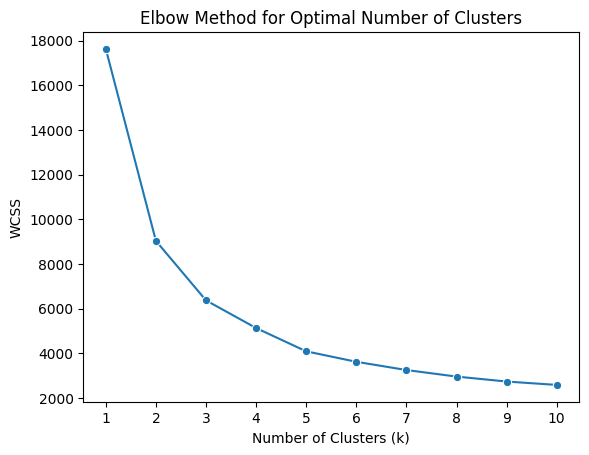

In [3]:
sns.lineplot(x=k_values, y=wcss, marker='o')
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.xticks(k_values)
plt.show()

### Insights and Results

The Elbow Method results show an abrupt reduction in WCSS between k=1 and k=4, indicating that increasing the number of clusters within this range significantly improves cluster compactness. However, after k=4, the rate of improvement begins to decrease progressively, suggesting diminishing returns from adding additional clusters.

Based on the observed inflection point in the curve, k=4 appears to provide an appropriate balance between cluster compactness and model simplicity. This result suggests that the customer base may naturally contain four distinguishable behavioral groups according to their RFM characteristics.

## Cluster Validation (Silhouette Score)

Although the Elbow Method provides a useful visual reference for selecting the number of clusters, an additional validation metric is required to evaluate the quality and separation of the generated clusters. For this purpose, the Silhouette Score is used as a complementary validation method.

The Silhouette Score measures how similar each data point is to its own cluster compared to other clusters. This metric combines both cluster cohesion and cluster separation, generating values that range from -1 to 1. Higher values indicate that observations are well grouped within their assigned clusters and clearly separated from neighboring clusters.

To validate the clustering structure, silhouette scores are calculated for multiple k values and compared through a line chart. This allows evaluating whether the selected number of clusters produces sufficiently distinct and meaningful customer segments.

In [9]:
from sklearn.metrics import silhouette_score

# Store silhouette scores
silhouette_scores = []

# Range of k values to test
k_values = range(2, 11)

# Compute silhouette score for each k
for k in k_values:
    
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        max_iter=300,
        n_init=10,
        random_state=42
    )

    cluster_labels = kmeans.fit_predict(df_rfm_scaled)

    score = silhouette_score(df_rfm_scaled, cluster_labels)

    silhouette_scores.append(score)

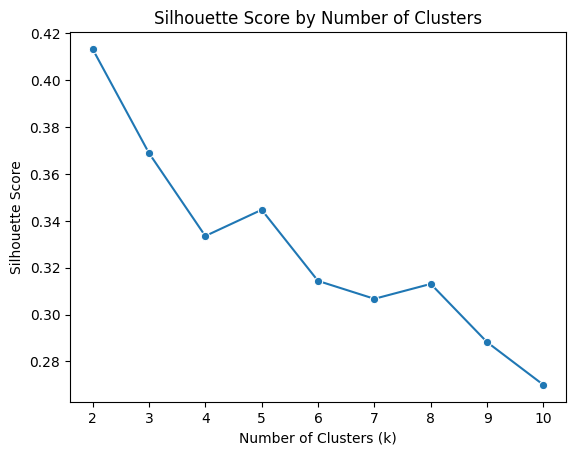

In [12]:
sns.lineplot(x=k_values, y=silhouette_scores, marker='o')
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")

plt.xticks(k_values)

plt.show()

### Insights and Results

The silhouette analysis shows that the highest score is achieved when k=2, indicating strong separation between two broad customer groups. However, such segmentation would provide limited business interpretability, as it would likely oversimplify customer behavior patterns.

For k=4, the silhouette score remains within an acceptable range while still maintaining a balance between cluster separation and business interpretability. Additionally, the score difference between k=4 and neighboring values is not substantial, suggesting that the clustering structure remains relatively stable.

Considering the combined results from both the Elbow Method and Silhouette Analysis, k=4 was selected as the optimal number of clusters, as it provides interpretable and actionable customer segments while preserving an acceptable clustering quality.